In [6]:
import torch
import torchquad
import matplotlib.pyplot as plt

from common import *

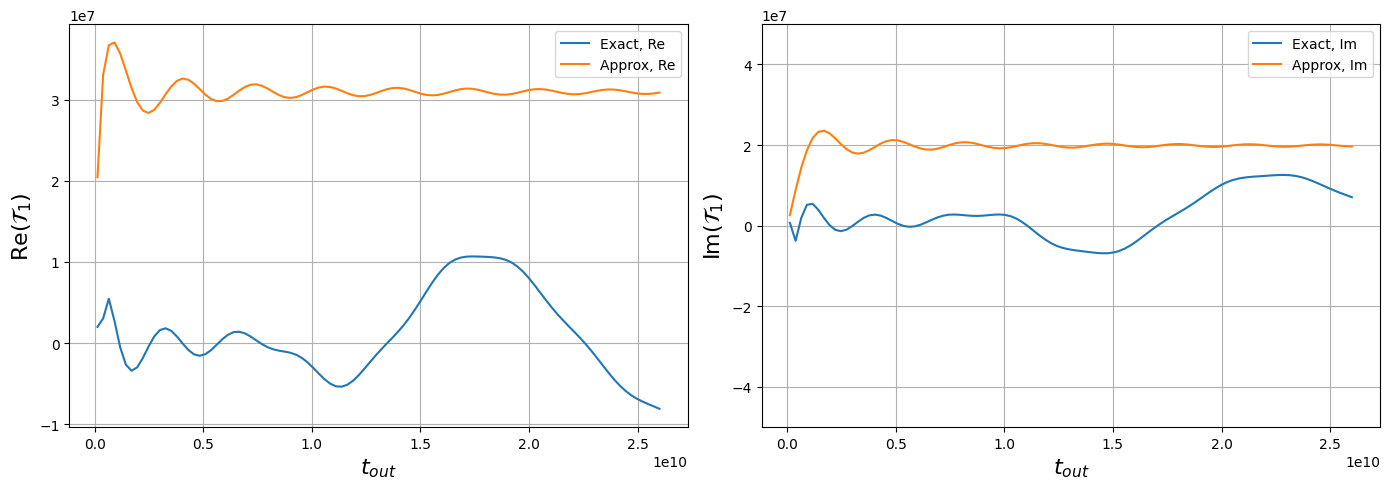

In [24]:
def TT_wide(si, li, pzi, sf, lf, pzf, kp, y, tin, tout):
    kz = pzi - pzf
    omega = torch.sqrt(kp**2 + kz**2)

    tint1 = Kprime(kp, pzi, pzf, tin, tout) / F0
    denominator = 1j * (omega - kz + 1j * eps)
    tint0 = (2 * torch.exp(1j * (omega - kz) * tin)) / denominator - \
            (2 * torch.exp(1j * (omega - kz) * tout)) / denominator

    term1 = Im1(si, li, sf, lf, y) * tint1
    term2 = rho_H * Ffun(si, li, sf, lf, y) * tint0
    term3 = Ip1(si, li, sf, lf, y) * tint1

    return torch.stack([term1, term2, term3])


def TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, y, tin, tout):
    # Преобразуем скалярные si, li, sf, lf в int для передачи в функции,
    # которые могут ожидать обычные числа (хотя лучше, если они тоже работают с тензорами).
    si, li, sf, lf = int(si), int(li), int(sf), int(lf)

    # Вычисляем константы один раз
    kz = pzi - pzf
    omega = torch.sqrt(kp**2 + kz**2)

    gl = torchquad.GaussLegendre()

    # --- Создаем ЕДИНУЮ векторизованную подынтегральную функцию ---
    def unified_integrand(t_batch, mode):
        # t_batch имеет форму [N, 1], преобразуем в [N] для удобства
        t = t_batch.squeeze(-1)

        # --- Векторизованные вычисления! Нет циклов! Все операции - torch.* ---
        En_i = En(si, li, pzi, t, HtoHc, sign, F0, m)
        En_f = En(sf, lf, pzf, t, HtoHc, sign, F0, m)
        z_i = z(si, li, pzi, t, HtoHc, sign, F0, m)
        z_f = z(sf, lf, pzf, t, HtoHc, sign, F0, m)

        # Общие части для обоих интегралов
        # Добавляем eps для численной стабильности, чтобы избежать деления на ноль
        eps = 1e-30
        prefactor_common = 1.0 / torch.sqrt(torch.clamp(En_i * En_f, min=eps))

        z_diff_sq = (z_i - z_f)**2
        exp1 = torch.exp(-z_diff_sq / (4 * sigma**2))

        int_en_diff = IntEn(si, li, pzi, t, HtoHc, sign, F0, m) - IntEn(sf, lf, pzf, t, HtoHc, sign, F0, m)
        z_sum = z_i + z_f
        phase = omega * t - int_en_diff - z_sum * (pzf - pzi + kz) / 2.0
        exp2 = torch.exp(1j * phase)

        # Различающиеся части
        if mode == 'integrand1':
            # Для tint1_Texact у нас просто 1.0 в качестве множителя
            # (но мы оставим его для общности)
            numerator = torch.ones_like(t, dtype=torch.complex128)
        elif mode == 'integrand0':
            # Для tint0_Texact
            numerator = -pzi - pzf - 2 * F0 * t + 1j * (z_i - z_f) / sigma**2
        else:
            raise ValueError("Unknown mode")

        return numerator * prefactor_common * exp1 * exp2

    # --- Вычисляем интегралы ---
    # Используем lambda-функции, чтобы передать параметр 'mode' в наш унифицированный интегранд

    # Интеграл для tint1
    tint1_Texact = gl.integrate(
        lambda t: unified_integrand(t, mode='integrand1'),
        dim=1, N=100, integration_domain=[[tin, tout]]
    )

    # Интеграл для tint0
    tint0_Texact = gl.integrate(
        lambda t: unified_integrand(t, mode='integrand0'),
        dim=1, N=100, integration_domain=[[tin, tout]]
    )

    # Собираем результат так же, как и раньше
    term1 = Im1(si, li, sf, lf, y) * tint1_Texact
    term2 = rho_H * Ffun(si, li, sf, lf, y) * tint0_Texact
    term3 = Ip1(si, li, sf, lf, y) * tint1_Texact # В вашем коде тут tint1, предполагаю, что это правильно

    return torch.stack([term1, term2, term3])

tspec = np.linspace (1.32e8, 2.6e10, 100) #- tint0 like approx

# tspec = np.linspace (1.32e11, 2e11, 100) #- difficult to see the beginning of difference for tint0, 4.3e9
# tspec = np.linspace(2.6e10, 2e11, 100)  
# tspec = np.linspace(1.1e11, 2e11, 100) 

tint1_Texact = [TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[0] / Im1(si, li, sf, lf, kp*rho_H) for T in tspec]
tint1 = [TT_wide(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[0] / Im1(si, li, sf, lf, kp*rho_H) for T in tspec]

# Create a figure with 2 subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot real parts on the first subplot
ax1.plot(tspec, np.array(tint1_Texact).real, label='Exact, Re')
ax1.plot(tspec, np.array(tint1).real, label='Approx, Re')
ax1.legend()
ax1.grid()
ax1.set_xlabel("$t_{out}$", fontsize=16)
ax1.set_ylabel("Re($\mathcal{T}_1$)", fontsize=16)

# Plot imaginary parts on the second subplot
ax2.plot(tspec, np.array(tint1_Texact).imag, label='Exact, Im')
ax2.plot(tspec, np.array(tint1).imag, label='Approx, Im')
ax2.legend()
ax2.grid()
ax2.set_xlabel("$t_{out}$", fontsize=16)
ax2.set_ylabel("Im($\mathcal{T}_1$)", fontsize=16)

plt.ylim(-5e7,5e7 )
# Adjust layout and show
plt.tight_layout()
plt.show()

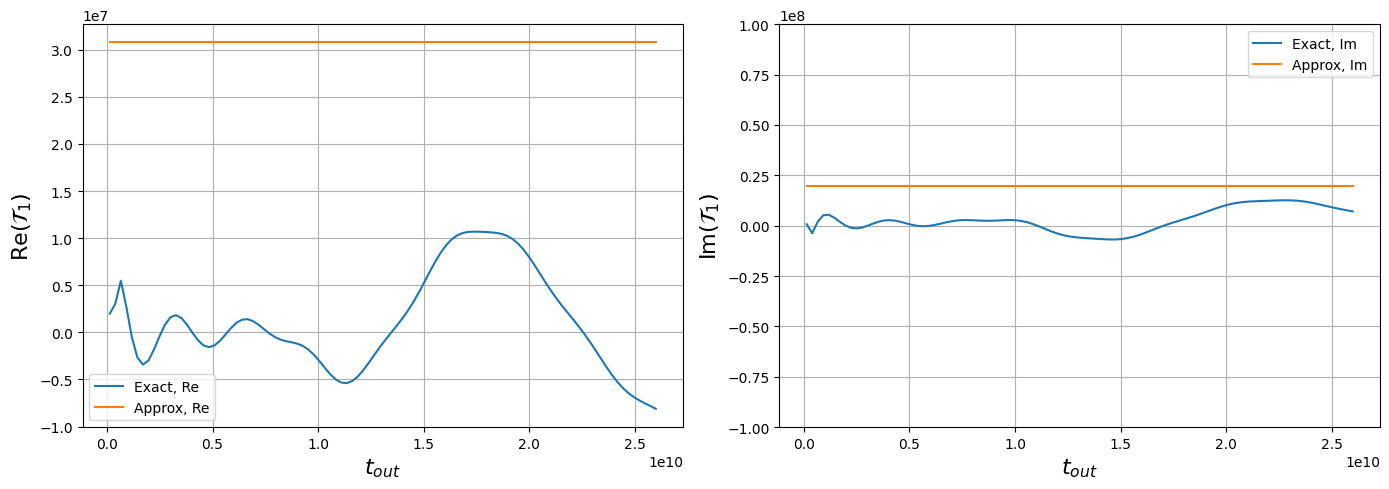

In [23]:
def compute_integral(
    kp: torch.Tensor,
    pzi: torch.Tensor,
    pzf: torch.Tensor,
    tin: torch.Tensor,
    tout: torch.Tensor,
    F0: torch.Tensor,
    eps: float = 1e-10,
    integration_steps: int = 1000,
) -> torch.Tensor:
    
    kz = pzi - pzf
    omega = torch.sqrt(kp**2 + kz**2)
    pz_avg = (pzi + pzf) / 2  # <pz>

    integrator = torchquad.GaussLegendre()

    # Определяем подынтегральную функцию
    def integrand(t: torch.Tensor) -> torch.Tensor:
        return (1 / (t + pz_avg / F0 + eps)) * torch.exp(1j * (omega - kz) * t)

    # Вычисляем интеграл от tin до tout
    integral = integrator.integrate(
        integrand,
        dim=1,  # Размерность интегрирования (1D)
        N=integration_steps,
        integration_domain=[[tin, tout]]
        
    )

    return integral / F0

def TT_wide_1(
    si, li, pzi, sf, lf, pzf, kp, y, tin, tout, F0, eps=1e-10, integration_steps=100
):
    kz = pzi - pzf
    omega = torch.sqrt(kp**2 + kz**2)
    y = kp*rho_H

    # Вычисляем интеграл методом Гаусса-Лежандра
    tint1 = compute_integral(
        kp, pzi, pzf, tin, tout, F0, eps=eps, integration_steps=integration_steps
    )

    denominator = 1j * (omega - kz + 1j * eps)
    tint0 = (
        2 * torch.exp(1j * (omega - kz) * tin) / denominator
        - 2 * torch.exp(1j * (omega - kz) * tout) / denominator
    )

    term1 = Im1(si, li, sf, lf, y) * tint1
    term2 = rho_H * Ffun(si, li, sf, lf, y) * tint0
    term3 = Ip1(si, li, sf, lf, y) * tint1

    return torch.stack([term1, term2, term3]), tint1


tspec = np.linspace (1.32e8, 2.6e10, 100) #- tint0 like approx

# tspec = np.linspace (1.32e11, 2e11, 100) #- difficult to see the beginning of difference for tint0, 4.3e9
# tspec = np.linspace(2.6e10, 2e11, 100)  
# tspec = np.linspace(1.1e11, 2e11, 100) 

tint1_Texact = [TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[0] / Im1(si, li, sf, lf, kp*rho_H) for T in tspec]
term1 = [TT_wide_1(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, t_out, F0, eps=1e-30, integration_steps=100)[0][0] / Im1(si, li, sf, lf, kp*rho_H) for T in tspec]
tint1 = [TT_wide_1(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, t_out, F0, eps=1e-30, integration_steps=100)[1] / Im1(si, li, sf, lf, kp*rho_H) for T in tspec]

# Create a figure with 2 subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot real parts on the first subplot
ax1.plot(tspec, np.array(tint1_Texact).real, label='Exact, Re')
ax1.plot(tspec, np.array(term1).real, label='Approx, Re')
#ax1.plot(tspec, np.array(tint1).real, label='Int, Re')
ax1.legend()
ax1.grid()
ax1.set_xlabel("$t_{out}$", fontsize=16)
ax1.set_ylabel("Re($\mathcal{T}_1$)", fontsize=16)

# Plot imaginary parts on the second subplot
ax2.plot(tspec, np.array(tint1_Texact).imag, label='Exact, Im')
ax2.plot(tspec, np.array(term1).imag, label='Approx, Im')
ax2.legend()
ax2.grid()
ax2.set_xlabel("$t_{out}$", fontsize=16)
ax2.set_ylabel("Im($\mathcal{T}_1$)", fontsize=16)
plt.ylim(-10e7,10e7 )
# Adjust layout and show
plt.tight_layout()
plt.show()

